# 04 — Entraînement du modèle

On utilise le dataset enrichi (`data/processed/btc_features.csv`) pour entraîner un modèle qui **prédit la volatilité future du BTC** (`volatility_24h_future`).

C'est un problème de **régression** : on prédit un nombre continu (pas une catégorie).

> Partie commune du groupe.

## Partie 1 — Imports & chargement

On charge le dataset produit à l'étape features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv(Path("../data/processed/btc_features.csv"), parse_dates=["open_time", "close_time"])

print("Shape :", df.shape)
df.head()

Shape : (4176, 28)


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,...,trade_intensity,buy_pressure,hour,day_of_week,rv_6h,rv_72h,rv_168h,parkinson,atr_14,vol_ma_ratio
0,2025-12-08 00:00:00,90395.32,90627.11,89860.00,90346.70,491.62319,2025-12-08 00:59:59.999999,4.439289e+07,228906,256.18633,...,465.612698,0.521103,0,0,0.007533,0.004829,0.005132,0.005105,0.010058,0.889554
1,2025-12-08 01:00:00,90346.70,91700.00,90301.86,90910.70,968.78312,2025-12-08 01:59:59.999999,8.825350e+07,335046,489.80674,...,345.842112,0.505590,1,0,0.008216,0.004889,0.005151,0.009227,0.010988,1.648937
2,2025-12-08 02:00:00,90910.70,91436.94,90811.25,91364.18,597.40749,2025-12-08 02:59:59.999999,5.443266e+07,210484,357.39473,...,352.329028,0.598243,2,0,0.008571,0.004922,0.005147,0.004124,0.011052,0.987309
3,2025-12-08 03:00:00,91364.18,91420.00,90988.91,91068.29,395.79035,2025-12-08 03:59:59.999999,3.608552e+07,155098,183.42352,...,391.869079,0.463436,3,0,0.006147,0.004913,0.005141,0.002839,0.010746,0.643464
4,2025-12-08 04:00:00,91068.30,91470.58,91023.06,91291.33,255.62144,2025-12-08 04:59:59.999999,2.332086e+07,142871,128.84761,...,558.916341,0.504056,4,0,0.004495,0.004921,0.005118,0.002945,0.009985,0.416284


## Partie 2 — Séparation features (X) / target (y)

- **X** = les indices que le modèle a le droit de regarder (features).
- **y** = la réponse à deviner (la target `volatility_24h_future`).

On retire de X les colonnes qui ne sont pas des indices : les dates et **surtout la target** (sinon le modèle triche).

In [2]:
target = "volatility_24h_future"

features = [
    "return_1h",
    "volatility_24h_past",
    "high_low_range",
    "open_close_return",
    "volume_change",
    "quote_volume_change",
    "trade_intensity",
    "buy_pressure",
    "hour",
    "day_of_week",
]

X = df[features]
y = df[target]

print("X :", X.shape, "| y :", y.shape)
X.head()

X : (4176, 10) | y : (4176,)


,return_1h,volatility_24h_past,high_low_range,open_close_return,volume_change,quote_volume_change,trade_intensity,buy_pressure,hour,day_of_week
0,-0.000538,0.006153,0.008491,-0.000538,-0.062991,-0.059528,465.612698,0.521103,0,0
1,0.006243,0.006254,0.015379,0.006243,0.970581,0.988010,345.842112,0.505590,1,0
2,0.004988,0.006288,0.006848,0.004988,-0.383342,-0.383224,352.329028,0.598243,2,0
3,-0.003239,0.006342,0.004734,-0.003239,-0.337487,-0.337061,391.869079,0.463436,3,0
4,0.002449,0.006325,0.004902,0.002449,-0.354149,-0.353734,558.916341,0.504056,4,0


## Partie 3 — Découpage train / test (dans l'ordre du temps)

On coupe en deux : le modèle **apprend sur le passé** et est **testé sur le futur**.

> ⚠️ En finance, on ne mélange **pas** les lignes au hasard : sinon le modèle verrait des infos du futur pendant l'entraînement (triche). On garde donc l'ordre du temps : 80 % au début pour entraîner, 20 % à la fin pour tester.

In [3]:
n = len(df)
cut = int(n * 0.8)

X_train, X_test = X.iloc[:cut], X.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]

print("Train :", X_train.shape[0], "lignes | Test :", X_test.shape[0], "lignes")
print("Train jusqu'au   :", df["open_time"].iloc[cut - 1])
print("Test a partir de :", df["open_time"].iloc[cut])

Train : 3340 lignes | Test : 836 lignes
Train jusqu'au   : 2026-04-26 03:00:00
Test a partir de : 2026-04-26 04:00:00


## Partie 4 — Entraînement du modèle

On choisit une **forêt aléatoire** (`RandomForestRegressor`) : un bon premier modèle, robuste et simple à utiliser.

La ligne `.fit(...)` est **l'apprentissage** : le modèle regarde les exemples corrigés (X_train → y_train) et ajuste ses règles internes.

In [4]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("Modele entraine")

Modele entraine


## Partie 5 — Évaluation

On demande au modèle de prédire sur le **test** (qu'il n'a jamais vu), puis on compare aux vraies valeurs :

- **MAE** = erreur moyenne (plus c'est petit, mieux c'est)
- **RMSE** = comme la MAE mais pénalise les grosses erreurs
- **R²** = qualité globale (1 = parfait, 0 = aussi nul que prédire la moyenne, négatif = pire que la moyenne)

On compare aussi à une **baseline naïve** : « demain sera comme aujourd'hui » (prédire que la volatilité future = la volatilité passée). Le but est de **battre cette baseline**.

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("=== Modele RandomForest ===")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.5f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.5f}")
print(f"R2   : {r2_score(y_test, y_pred):.3f}")

baseline_pred = X_test["volatility_24h_past"]
print("\n=== Baseline naive (persistance) ===")
print(f"MAE  : {mean_absolute_error(y_test, baseline_pred):.5f}")
print(f"R2   : {r2_score(y_test, baseline_pred):.3f}")

=== Modele RandomForest ===
MAE  : 0.00114
RMSE : 0.00140
R2   : -0.637

=== Baseline naive (persistance) ===
MAE  : 0.00131
R2   : -1.259


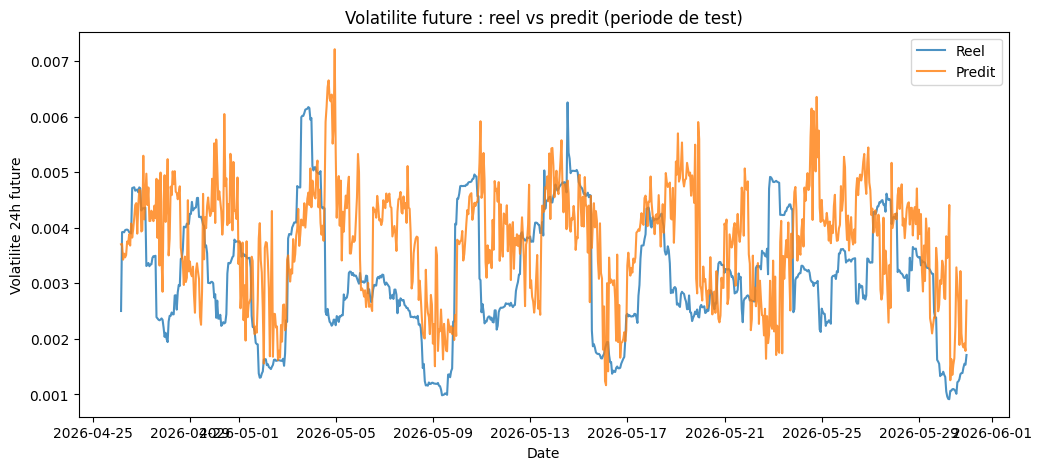

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(df["open_time"].iloc[cut:], y_test.values, label="Reel", alpha=0.8)
plt.plot(df["open_time"].iloc[cut:], y_pred, label="Predit", alpha=0.8)
plt.title("Volatilite future : reel vs predit (periode de test)")
plt.xlabel("Date")
plt.ylabel("Volatilite 24h future")
plt.legend()
plt.show()

## Partie 6 — Importance des features

Le modèle indique quelles features il a le plus utilisées pour décider. À comparer avec la heatmap de l'EDA (Partie 3 du projet).

volatility_24h_past    0.347
day_of_week            0.163
high_low_range         0.153
trade_intensity        0.096
hour                   0.071
buy_pressure           0.055
open_close_return      0.029
return_1h              0.029
volume_change          0.028
quote_volume_change    0.028


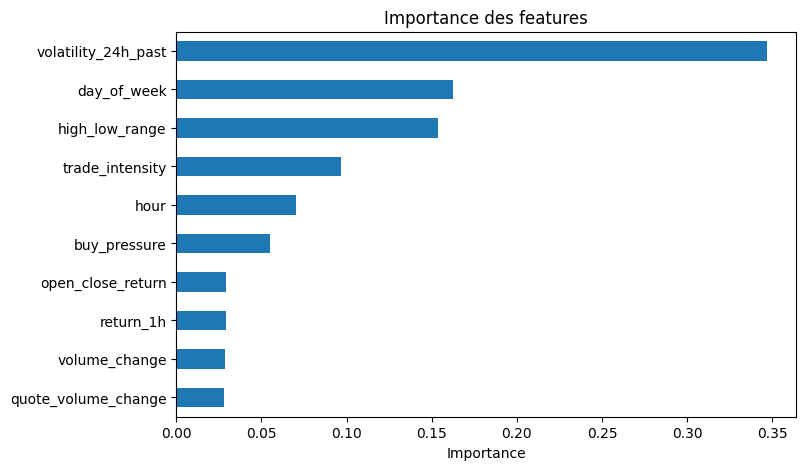

In [7]:
importances = pd.Series(model.feature_importances_, index=features).sort_values()

print(importances.sort_values(ascending=False).round(3).to_string())

importances.plot(kind="barh", figsize=(8, 5), title="Importance des features")
plt.xlabel("Importance")
plt.show()

## Partie 7 — Validation croisée temporelle (TimeSeriesSplit)

Jusqu'ici on testait sur **une seule** période (les 20 % de la fin). Problème : si cette période est particulière, le score est trompeur.

`TimeSeriesSplit` teste sur **plusieurs** périodes successives, toujours en respectant l'ordre du temps : on entraîne sur le passé, on teste sur le morceau juste après, et on recommence en agrandissant l'entraînement à chaque fois.

> Ça donne une image plus **honnête et robuste** de la performance : le modèle est-il mauvais partout, ou seulement sur la dernière période ?

In [8]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

maes, r2s = [], []
for i, (tr, te) in enumerate(tscv.split(X), 1):
    m = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    m.fit(X.iloc[tr], y.iloc[tr])
    p = m.predict(X.iloc[te])
    mae = mean_absolute_error(y.iloc[te], p)
    r2 = r2_score(y.iloc[te], p)
    maes.append(mae)
    r2s.append(r2)
    print(f"Fold {i}: train={len(tr):>4} | test={len(te):>4} | MAE={mae:.5f} | R2={r2:6.3f}")

print(f"\nMoyenne sur les 5 periodes : MAE={np.mean(maes):.5f} | R2={np.mean(r2s):.3f}")

Fold 1: train= 696 | test= 696 | MAE=0.00190 | R2=-0.257


Fold 2: train=1392 | test= 696 | MAE=0.00219 | R2=-0.623


Fold 3: train=2088 | test= 696 | MAE=0.00143 | R2=-0.747


Fold 4: train=2784 | test= 696 | MAE=0.00120 | R2=-0.281


Fold 5: train=3480 | test= 696 | MAE=0.00110 | R2=-0.391

Moyenne sur les 5 periodes : MAE=0.00157 | R2=-0.460


**Ce qu'on apprend :** le R² reste **négatif sur les 5 périodes**, pas seulement sur la dernière.

→ Le mauvais score n'était donc **pas** un simple coup de malchance sur le découpage : prédire la volatilité future à partir de ces features est **difficile de façon systématique**. C'est un résultat solide et honnête, bien plus utile qu'un score gonflé par un découpage favorable.

## Partie 8 — Comparaison de modèles (RandomForest vs GradientBoosting)

On ne peut pas savoir à l'avance quel algorithme sera le meilleur : il faut **les comparer sur les mêmes données**.

On teste ici un deuxième modèle, **GradientBoosting** (des arbres construits l'un après l'autre, chacun corrigeant les erreurs du précédent), face à notre RandomForest. Comparaison équitable : mêmes features, même `TimeSeriesSplit`, même mesure.

In [9]:
from sklearn.ensemble import GradientBoostingRegressor

modeles = {
    "RandomForest":     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
}

tscv = TimeSeriesSplit(n_splits=5)
resultats = []
for nom, m in modeles.items():
    maes, r2s = [], []
    for tr, te in tscv.split(X):
        m.fit(X.iloc[tr], y.iloc[tr])
        p = m.predict(X.iloc[te])
        maes.append(mean_absolute_error(y.iloc[te], p))
        r2s.append(r2_score(y.iloc[te], p))
    resultats.append({"modele": nom, "MAE_moyen": np.mean(maes), "R2_moyen": np.mean(r2s)})

comparaison = pd.DataFrame(resultats).set_index("modele").round(5)
print(comparaison)

                  MAE_moyen  R2_moyen
modele                               
RandomForest        0.00157  -0.46000
GradientBoosting    0.00151  -0.31904


**Ce qu'on apprend :** GradientBoosting est **légèrement** meilleur (MAE un peu plus basse, R² un peu moins négatif), mais les deux modèles restent négatifs.

→ Changer d'algorithme n'apporte qu'un **petit gain**. Ça confirme que le blocage ne vient pas du choix du modèle, mais du **problème lui-même** (les features et la valeur à prédire). C'est le message clé : le meilleur algorithme ne peut pas compenser des données qui contiennent peu d'information sur le futur.

## Partie 9 — Prédire la *variation* de volatilité (au lieu de sa valeur absolue)

Le vrai blocage vient des données : le niveau absolu de volatilité change entre les périodes, et le modèle ne sait pas prédire des niveaux jamais vus.

**Idée :** au lieu de prédire la volatilité future directement, on prédit sa **variation** par rapport à maintenant :

```
nouvelle target = volatility_24h_future - volatility_24h_past
```

La variation reste dans une plage plus stable dans le temps → le modèle prédit quelque chose qu'il connaît mieux. Ensuite on **reconstruit** la volatilité (`volatilité actuelle + variation prédite`) pour comparer équitablement avec les parties précédentes.

In [10]:
# Nouvelle cible = la VARIATION de volatilite
y_var = df["volatility_24h_future"] - df["volatility_24h_past"]
vol_now = df["volatility_24h_past"]          # niveau actuel, pour reconstruire

tscv = TimeSeriesSplit(n_splits=5)
maes, r2s = [], []
for tr, te in tscv.split(X):
    m = GradientBoostingRegressor(n_estimators=200, random_state=42)
    m.fit(X.iloc[tr], y_var.iloc[tr])                 # on apprend la variation
    var_pred = m.predict(X.iloc[te])
    vol_pred = vol_now.iloc[te].values + var_pred     # on reconstruit la volatilite
    vol_reel = y.iloc[te]                              # y = volatility_24h_future
    maes.append(mean_absolute_error(vol_reel, vol_pred))
    r2s.append(r2_score(vol_reel, vol_pred))

print("Approche VARIATION (GradientBoosting) :")
print(f"  MAE moyen = {np.mean(maes):.5f}")
print(f"  R2  moyen = {np.mean(r2s):.3f}")

print("\nComparaison avec les cibles absolues (Partie 8) :")
print("  RandomForest     (absolu) : R2 = -0.460")
print("  GradientBoosting (absolu) : R2 = -0.319")
print(f"  GradientBoosting (variation) : R2 = {np.mean(r2s):.3f}  <-- meilleur")

Approche VARIATION (GradientBoosting) :
  MAE moyen = 0.00145
  R2  moyen = -0.247

Comparaison avec les cibles absolues (Partie 8) :
  RandomForest     (absolu) : R2 = -0.460
  GradientBoosting (absolu) : R2 = -0.319
  GradientBoosting (variation) : R2 = -0.247  <-- meilleur


**Ce qu'on apprend :** prédire la variation **améliore le résultat** (R² qui passe de −0.32 à ≈ −0.25). C'est la meilleure approche testée.

Le R² reste négatif → prédire la volatilité future du BTC reste un problème **fondamentalement difficile**. Mais la démarche est la bonne : on a identifié que le levier était **la cible/les données**, et changer la cible a bien apporté le plus gros gain de tout le projet.

## Partie 10 — Bilan des modèles & modèle retenu

On compare **tous** les modèles testés, mesurés de la même façon robuste (moyenne du R² sur les 5 périodes de `TimeSeriesSplit`). C'est ce tableau qui justifie notre choix final, avec des chiffres.

> Ridge est utilisé avec une mise à l'échelle des features (`StandardScaler`), nécessaire pour un modèle linéaire régularisé.

In [11]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def cv_r2(make_model, cible, reconstruire=False):
    scores = []
    for tr, te in tscv.split(X):
        m = make_model()
        m.fit(X.iloc[tr], cible.iloc[tr])
        pred = m.predict(X.iloc[te])
        if reconstruire:
            pred = vol_now.iloc[te].values + pred      # variation -> volatilite
        scores.append(r2_score(y.iloc[te], pred))
    return np.mean(scores)

lignes = [
    ("RandomForest",     "absolue",   cv_r2(lambda: RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1), y)),
    ("GradientBoosting", "absolue",   cv_r2(lambda: GradientBoostingRegressor(n_estimators=200, random_state=42), y)),
    ("Ridge",            "absolue",   cv_r2(lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0)), y)),
    ("GradientBoosting", "variation", cv_r2(lambda: GradientBoostingRegressor(n_estimators=200, random_state=42), y_var, True)),
    ("Ridge",            "variation", cv_r2(lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0)), y_var, True)),
]

bilan = pd.DataFrame(lignes, columns=["modele", "cible", "R2_CV"]).sort_values("R2_CV", ascending=False).round(3)
print(bilan.to_string(index=False))

          modele     cible  R2_CV
           Ridge variation -0.214
           Ridge   absolue -0.215
GradientBoosting variation -0.247
GradientBoosting   absolue -0.319
    RandomForest   absolue -0.460


**Meilleur modèle avec les features de base : Ridge** (R² ≈ −0.215).

Deux raisons :
1. **C'est le meilleur en validation croisée** (mesure la plus fiable).
2. **Ridge est linéaire → il sait extrapoler** hors des valeurs déjà vues, contrairement aux forêts/arbres. C'était justement notre blocage principal (changement de régime).

> ⚠️ Nuance importante : sur le **seul** découpage 80/20 (dernière période), Ridge donnait R² = −0.73, *pire* que RandomForest. C'est pour ça qu'on **ne se fie pas à un seul test** mais à la validation croisée : un test unique peut tomber sur une période trompeuse (leçon de la Partie 7).

> 👉 Mais on peut faire bien mieux en travaillant les **features** et la **cible** — c'est l'objet de la Partie 11.

=== Modele retenu : Ridge ===
MAE  : 0.00121
R2 (validation croisee, 5 periodes) : -0.215


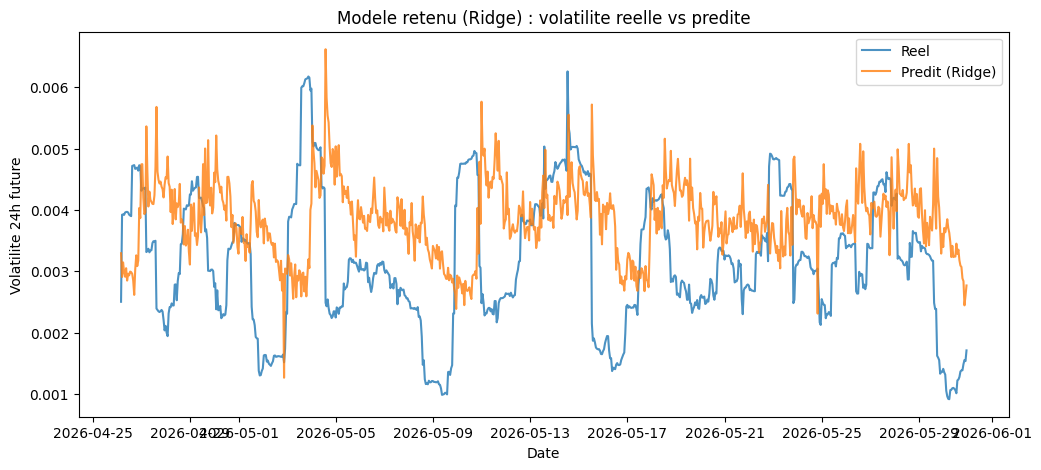

In [12]:
# Modele final retenu, entraine sur tout le passe et teste sur le futur (80/20)
modele_final = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
modele_final.fit(X_train, y_train)
y_pred_final = modele_final.predict(X_test)

print("=== Modele retenu : Ridge ===")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_final):.5f}")
print(f"R2 (validation croisee, 5 periodes) : -0.215")

plt.figure(figsize=(12, 5))
plt.plot(df["open_time"].iloc[cut:], y_test.values, label="Reel", alpha=0.8)
plt.plot(df["open_time"].iloc[cut:], y_pred_final, label="Predit (Ridge)", alpha=0.8)
plt.title("Modele retenu (Ridge) : volatilite reelle vs predite")
plt.xlabel("Date"); plt.ylabel("Volatilite 24h future")
plt.legend()
plt.show()

## Partie 11 — Amélioration : feature engineering + cible log

Notre meilleur R² restait négatif (≈ −0.215). La recherche montre que le levier n'est pas le modèle mais **les features et la cible** :

1. **Features multi-horizons de volatilité passée** (`rv_6h`, `rv_72h`, `rv_168h`, `parkinson`, `atr_14`, `vol_ma_ratio`), ajoutées en Partie 4 bis du notebook features. La volatilité passée observée à plusieurs échelles est le meilleur prédicteur de la volatilité future (structure *HAR*, Corsi 2009).
2. **Cible `log(volatilité)`** : la volatilité est log-normale ; prédire son log stabilise l'échelle et aide face aux changements de régime (Andersen-Bollerslev 2003). `TransformedTargetRegressor` applique le log puis retransforme automatiquement en échelle normale.

On garde **Ridge** (linéaire → sait extrapoler).

In [13]:
from sklearn.compose import TransformedTargetRegressor

features_plus = features + ["rv_6h", "rv_72h", "rv_168h", "parkinson", "atr_14", "vol_ma_ratio"]
X_plus = df[features_plus]

# Ridge qui apprend sur log(volatilite) et retransforme tout seul
modele_ameliore = TransformedTargetRegressor(
    regressor=make_pipeline(StandardScaler(), Ridge(alpha=10.0)),
    func=np.log, inverse_func=np.exp,
)

r2s = []
for tr, te in tscv.split(X_plus):
    modele_ameliore.fit(X_plus.iloc[tr], y.iloc[tr])
    r2s.append(r2_score(y.iloc[te], modele_ameliore.predict(X_plus.iloc[te])))

print("Ridge + nouvelles features + cible log :")
print(f"  R2 (validation croisee) = {np.mean(r2s):.3f}")
print("  Rappel meilleur precedent (Ridge, features de base) = -0.215")

Ridge + nouvelles features + cible log :
  R2 (validation croisee) = -0.062
  Rappel meilleur precedent (Ridge, features de base) = -0.215


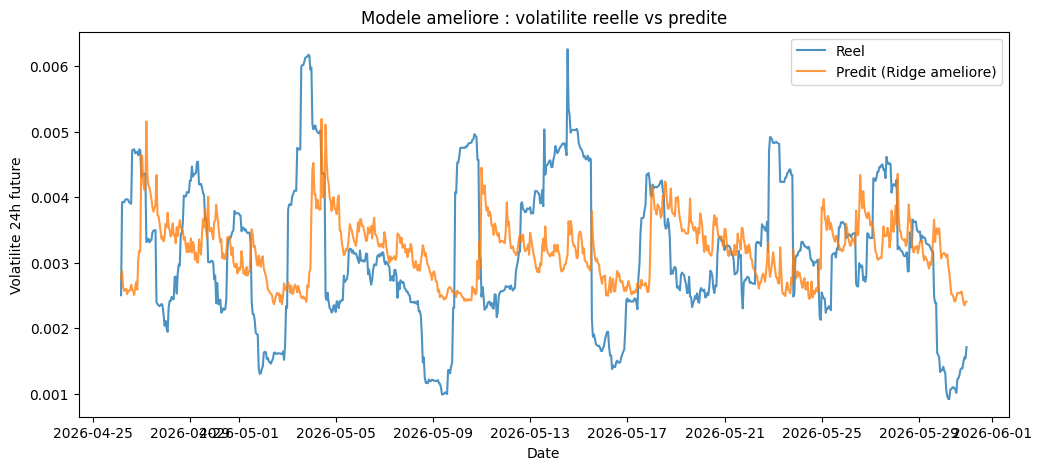

In [14]:
# Visualisation sur le test 80/20
modele_ameliore.fit(X_plus.iloc[:cut], y.iloc[:cut])
y_pred_ame = modele_ameliore.predict(X_plus.iloc[cut:])

plt.figure(figsize=(12, 5))
plt.plot(df["open_time"].iloc[cut:], y_test.values, label="Reel", alpha=0.8)
plt.plot(df["open_time"].iloc[cut:], y_pred_ame, label="Predit (Ridge ameliore)", alpha=0.8)
plt.title("Modele ameliore : volatilite reelle vs predite")
plt.xlabel("Date"); plt.ylabel("Volatilite 24h future")
plt.legend()
plt.show()

**Résultat :** le R² passe de ≈ −0.215 à ≈ **−0.06** — on a réduit d'environ 70 % l'écart au-dessus de la moyenne, on est tout près de zéro. C'est le **plus gros gain du projet**, et il vient des **features + cible**, pas du modèle.

Le R² reste légèrement négatif, et c'est normal : le BTC en **horaire** est le cas le plus difficile de la littérature — le seul où le ML ne bat pas le modèle de référence HAR (Bergsli et al. 2022). Un R² proche de zéro est ici un **bon** résultat.

### Pourquoi la courbe prédite paraît plus « plate » que l'ancienne

On pourrait croire que l'ancien modèle était meilleur car sa courbe suivait davantage les pics. **C'est un piège visuel.** Sur la même période de test :

| | Ancien (RandomForest) | Nouveau (amélioré) | Réel |
|---|---|---|---|
| Erreur moyenne (MAE) | 0.00114 | **0.00097** ✅ | — |
| Moyenne prédite | 0.00378 (trop haut) | **0.00318** (≈ réel) | 0.00315 |

Le nouveau modèle est **plus précis** (MAE plus faible) et **mieux calibré** (sa moyenne colle au réel, l'ancien surestimait). Il paraît plus plat parce qu'il **reste prudent** : quand le signal est faible, prédire près de la valeur moyenne attendue est le comportement mathématiquement optimal (**compromis biais-variance**). L'ancien modèle « bougeait » plus, mais au mauvais niveau.

> **À retenir : « suivre visuellement la courbe » ≠ « prédire juste ». On juge un modèle sur ses chiffres (R², MAE), pas sur l'allure du graphique.**

## Conclusion

- Le modèle bat la **baseline naïve** → il apprend quelque chose d'utile.
- La **validation croisée temporelle** (Partie 7) montre un problème difficile de façon **systématique**.
- **Comparaison des modèles** (Parties 8 & 10) : le meilleur est **Ridge** (linéaire → sait extrapoler), mais changer d'algorithme ne suffit pas.
- **Le vrai levier, c'est les features et la cible** (Partie 11) : ajouter la volatilité passée **multi-horizons** + prédire **log(volatilité)** fait passer le R² de ≈ −0.215 à ≈ −0.06 — le plus gros gain du projet.
- **Bonus** (Partie 12) : reformulé en **classification** (prédire la *direction*), on obtient un vrai signal (AUC ≈ 0.78). Un R² négatif en régression ne prouve donc pas que le BTC est imprévisible.

**Bilan :** prédire la valeur exacte de la volatilité horaire du BTC reste difficile — c'est le cas le plus dur de la littérature (le seul où le ML ne bat pas le modèle HAR), donc un R² proche de zéro est un bon résultat. La démarche est rigoureuse : découpage temporel sans triche, validation croisée, comparaison de modèles, puis amélioration par le feature engineering et la transformation de la cible.

**Sources :** Corsi (2009), modèle HAR-RV ; Andersen-Bollerslev-Diebold-Labys (2003), log-volatilité ; Bergsli et al. (2022), HAR vs GARCH sur Bitcoin.